<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab06/lab06B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksploracyjna analiza danych (EDA) na zbiorze Filmweb+

W tym notatniku przećwiczymy:

1. Pobieranie i ładowanie datasetu **Filmweb+** z repozytorium GitHub
2. Podstawową inspekcję struktury danych
3. Analizę rozkładu klas (etykiet sentymentu)
4. Analizę statystyk tekstowych (długość recenzji, liczba słów)
5. Wizualizację wyników za pomocą `matplotlib` i `seaborn`
6. Wstępną analizę zawartości tekstowej (najczęstsze słowa)

---
## 0. Pobranie datasetu i import bibliotek

Dataset **Filmweb+** to zbiór 27 202 polskich recenzji filmowych ze stron takich jak Filmweb, Film.org.pl, Kinoblog, FDB i blogfilmowy24. Dane są dostępne w formacie CSV w repozytorium GitHub.

In [ ]:
# Pobranie repozytorium z GitHuba i rozpakowanie danych
!git clone https://github.com/narolski/filmwebplus.git
!gunzip -k filmwebplus/filmwebplus.gz

Cloning into 'filmwebplus'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 5), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 40.56 MiB | 27.18 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
print("Wszystko gotowe!")

Wszystko gotowe!


---
## 1. Przykład z omówieniem -- ładowanie datasetu Filmweb+

### Czym jest Filmweb+?

**Filmweb+** to dataset polskich recenzji filmowych stworzony na potrzeby klasyfikacji sentymentu na poziomie dokumentu (Narolski, 2020). Zawiera 27 202 recenzje podzielone na klasy:
- **Pozytywny (2)** -- 6 971 recenzji
- **Neutralny (1)** -- 9 436 recenzji
- **Negatywny (0)** -- 3 085 recenzji
- **Nieoznaczony (-1)** -- 7 710 recenzji

Recenzje mają średnio 514 słów (3582 znaki) na dokument, co czyni je znacznie dłuższymi niż typowe zbiory recenzji produktowych.

In [ ]:
df = pd.read_csv("filmwebplus/filmwebplus", index_col=0)

# Usunięcie zbędnej kolumny indeksowej
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(type(df))
print(f"Kształt: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")

<class 'pandas.core.frame.DataFrame'>
Kształt: (27202, 2)
Kolumny: ['review', 'sentiment']


In [ ]:
# Podgląd pierwszych przykładów
df.head()

,review,sentiment
0,"""Melasa"" Carlosa Lechugi jest porównywana do ""...",0
1,"W ""Moim biegunie"" mnóstwo jest ładnych obrazkó...",0
2,"Siedem lat po premierze pierwszych ""Avengers"" ...",1
3,"Jesteśmy w obskurnej hotelowej toalecie, gdzie...",1
4,"Kto ma większego pecha od chłopaka, który za k...",1


### Interpretacja

DataFrame ma dwie kluczowe kolumny:
- `review` -- tekst recenzji filmowej
- `sentiment` -- etykieta sentymentu (wartość liczbowa: -1, 0, 1, 2)

W dalszej analizie skupimy się na recenzjach **oznaczonych** (sentiment ≠ -1), czyli tych z etykietami 0, 1 i 2.

### 1.1 Przygotowanie danych

Mapujemy numeryczne etykiety na czytelne nazwy i oddzielamy recenzje oznaczone od nieoznaczonych.

In [ ]:
# Mapowanie etykiet na czytelne nazwy
label_map = {
    -1: "nieoznaczony",
    0: "negatywny",
    1: "neutralny",
    2: "pozytywny"
}

df["label"] = df["sentiment"].map(label_map)

# Podział na oznaczone i nieoznaczone
df_labeled = df[df["sentiment"] != -1].copy()
df_unlabeled = df[df["sentiment"] == -1].copy()

print(f"Recenzje oznaczone:     {df_labeled.shape[0]}")
print(f"Recenzje nieoznaczone:  {df_unlabeled.shape[0]}")
print(f"Łącznie:                {df.shape[0]}")

Recenzje oznaczone:     19492
Recenzje nieoznaczone:  7710
Łącznie:                27202


In [ ]:
df_labeled.head(10)

,review,sentiment,label
0,"""Melasa"" Carlosa Lechugi jest porównywana do ""...",0,negatywny
1,"W ""Moim biegunie"" mnóstwo jest ładnych obrazkó...",0,negatywny
2,"Siedem lat po premierze pierwszych ""Avengers"" ...",1,neutralny
3,"Jesteśmy w obskurnej hotelowej toalecie, gdzie...",1,neutralny
4,"Kto ma większego pecha od chłopaka, który za k...",1,neutralny
5,Zaczyna się obrazem leżącej na łóżku i wzajemn...,1,neutralny
6,Reżyserka-debiutantka Jill Soloway już w pierw...,1,neutralny
7,"Wejście ""Świtu"" do kin to powód do świętowania...",2,pozytywny
8,An – bo taki jest oryginalny tytuł filmu Naomi...,1,neutralny
9,"Sylvester Stallone ma 64 lata na karku, ale me...",1,neutralny


In [ ]:
df_labeled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19492 entries, 0 to 1684
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     19492 non-null  object
 1   sentiment  19492 non-null  int64 
 2   label      19492 non-null  object
dtypes: int64(1), object(2)
memory usage: 609.1+ KB


### Interpretacja

Mamy 19 492 oznaczonych recenzji z trzema klasami sentymentu. Kolumna `review` to typ string (object), a `sentiment` to int64. Warto sprawdzić, czy nie ma brakujących wartości w tekście recenzji.

### 1.2 Rozkład klas (etykiet sentymentu)

Sprawdzamy, ile przykładów przypada na każdą klasę -- czy dane są zbalansowane?

In [ ]:
print("Rozkład klas w zbiorze oznaczonych recenzji:")
print(df_labeled["label"].value_counts())
print(f"\nProporcje:")
print(df_labeled["label"].value_counts(normalize=True).round(3))

Rozkład klas w zbiorze oznaczonych recenzji:
label
neutralny    9436
pozytywny    6971
negatywny    3085
Name: count, dtype: int64

Proporcje:
label
neutralny    0.484
pozytywny    0.358
negatywny    0.158
Name: proportion, dtype: float64


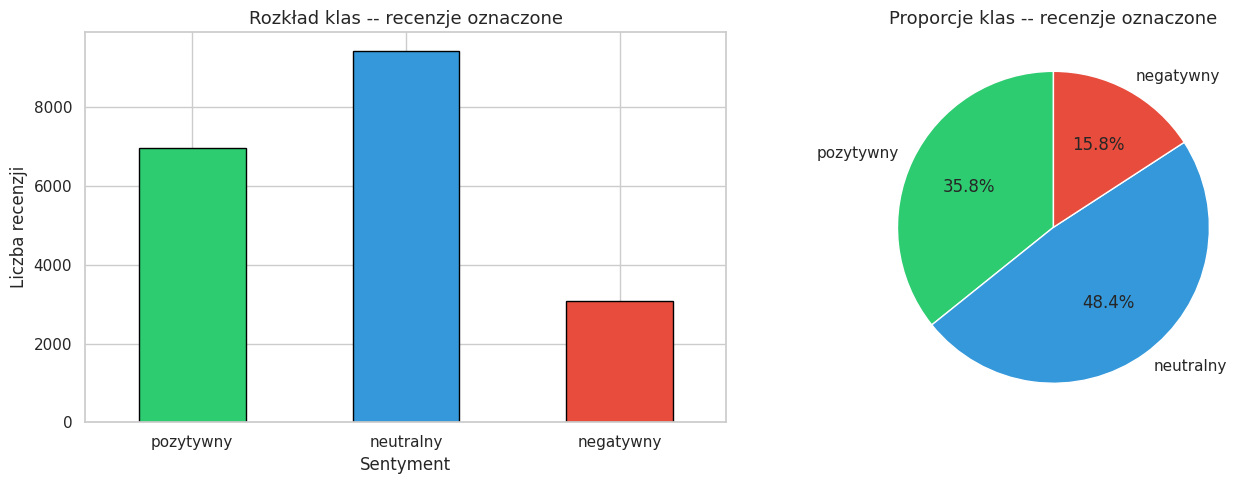

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres słupkowy
colors = ["#2ecc71", "#3498db", "#e74c3c"]
order = ["pozytywny", "neutralny", "negatywny"]
df_labeled["label"].value_counts().reindex(order).plot(
    kind="bar", ax=axes[0], color=colors, edgecolor="black"
)
axes[0].set_title("Rozkład klas -- recenzje oznaczone", fontsize=13)
axes[0].set_xlabel("Sentyment")
axes[0].set_ylabel("Liczba recenzji")
axes[0].tick_params(axis="x", rotation=0)

# Wykres kołowy
df_labeled["label"].value_counts().reindex(order).plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%", colors=colors, startangle=90
)
axes[1].set_ylabel("")
axes[1].set_title("Proporcje klas -- recenzje oznaczone", fontsize=13)

plt.tight_layout()
plt.show()

### Interpretacja

Rozkład klas pokazuje, czy dataset jest **zbalansowany** (równe proporcje) czy **niezbalansowany**. W Filmweb+ klasa neutralna dominuje, a negatywna jest najmniejsza. Nierównomierne proporcje mogą wpływać na jakość trenowania modeli -- klasy mniejszościowe mogą być gorzej rozpoznawane. W takich przypadkach stosuje się techniki takie jak oversampling, class weights lub metrykę F1 zamiast accuracy.

### 1.3 Analiza długości tekstów

Sprawdzamy rozkład długości recenzji (w znakach i w słowach) -- to ważna informacja przy wyborze maksymalnej długości sekwencji dla tokenizera. Filmweb+ jest specyficzny, bo zawiera bardzo długie recenzje (średnio 514 słów).

In [ ]:
df_labeled["num_chars"] = df_labeled["review"].str.len()
df_labeled["num_words"] = df_labeled["review"].str.split().str.len()

print("Statystyki długości (znaki):")
print(df_labeled["num_chars"].describe().round(1))
print(f"\nStatystyki długości (słowa):")
print(df_labeled["num_words"].describe().round(1))

Statystyki długości (znaki):
count    19492.0
mean      3484.7
std       1531.6
min        304.0
25%       2560.0
50%       3187.0
75%       4113.0
max      28777.0
Name: num_chars, dtype: float64

Statystyki długości (słowa):
count    19492.0
mean       501.3
std        218.3
min         43.0
25%        370.0
50%        459.0
75%        590.0
max       4039.0
Name: num_words, dtype: float64


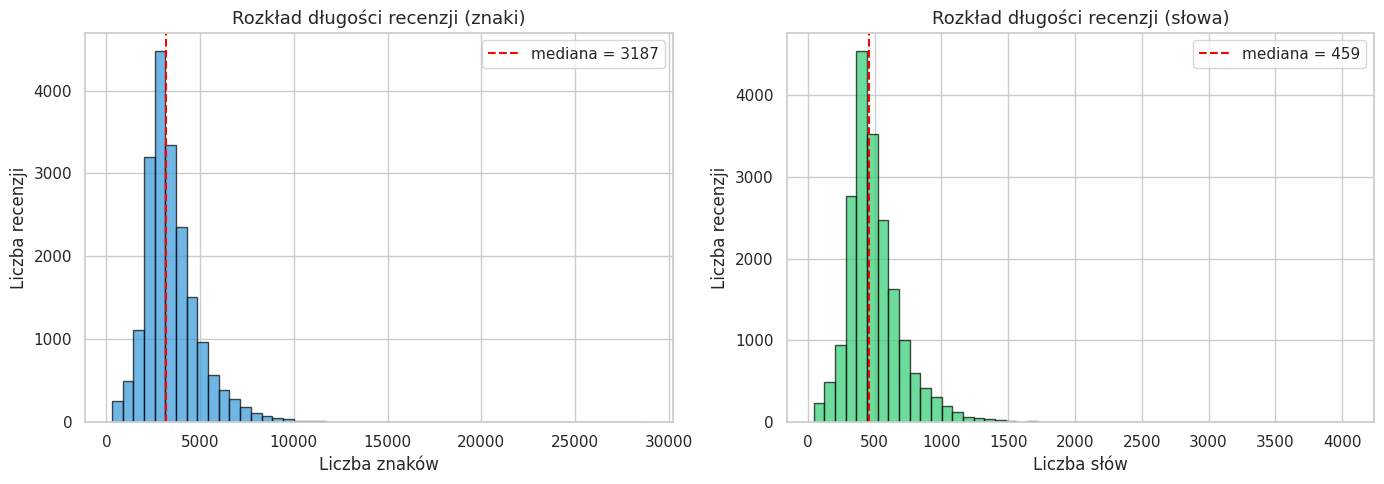

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_labeled["num_chars"], bins=50, color="#3498db", edgecolor="black", alpha=0.7)
axes[0].axvline(df_labeled["num_chars"].median(), color="red", linestyle="--", label=f'mediana = {df_labeled["num_chars"].median():.0f}')
axes[0].set_title("Rozkład długości recenzji (znaki)", fontsize=13)
axes[0].set_xlabel("Liczba znaków")
axes[0].set_ylabel("Liczba recenzji")
axes[0].legend()

axes[1].hist(df_labeled["num_words"], bins=50, color="#2ecc71", edgecolor="black", alpha=0.7)
axes[1].axvline(df_labeled["num_words"].median(), color="red", linestyle="--", label=f'mediana = {df_labeled["num_words"].median():.0f}')
axes[1].set_title("Rozkład długości recenzji (słowa)", fontsize=13)
axes[1].set_xlabel("Liczba słów")
axes[1].set_ylabel("Liczba recenzji")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretacja

Histogramy pokazują, że rozkład długości recenzji jest **prawoskośny** -- większość tekstów ma umiarkowaną długość, ale zdarzają się bardzo długie recenzje. Filmweb+ wyróżnia się na tle innych polskich datasetów sentymentu tym, że zawiera znacznie dłuższe dokumenty (średnio ~500 słów vs ~30 słów w PolEmo2.0).

### 1.4 Długość tekstu a sentyment

Czy istnieje związek między długością recenzji a jej sentymentem?

/tmp/ipykernel_11731/3623836144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_labeled, x="label", y="num_words", ax=ax, palette=colors,


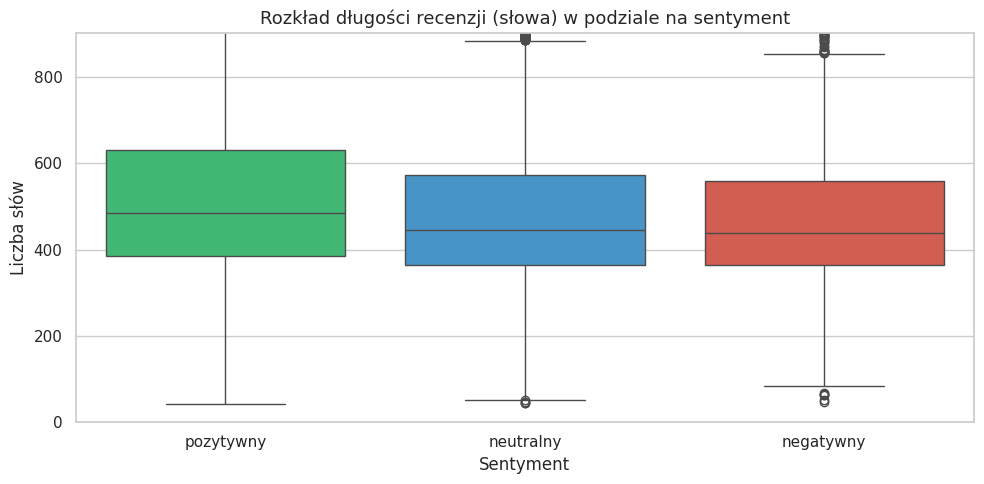

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_labeled, x="label", y="num_words", ax=ax, palette=colors,
            order=["pozytywny", "neutralny", "negatywny"])
ax.set_title("Rozkład długości recenzji (słowa) w podziale na sentyment", fontsize=13)
ax.set_xlabel("Sentyment")
ax.set_ylabel("Liczba słów")
ax.set_ylim(0, df_labeled["num_words"].quantile(0.95))

plt.tight_layout()
plt.show()

### Interpretacja

Boxplot pozwala porównać rozkłady długości tekstu między klasami. Mediana (linia wewnątrz pudełka), rozstęp międzykwartylowy (wysokość pudełka) i wartości odstające (kropki) dają obraz tego, czy niektóre kategorie sentymentu wiążą się z dłuższymi lub krótszymi recenzjami filmowymi.

### 1.5 Najczęstsze słowa

Prosta analiza frekwencji słów pozwala zobaczyć, jakie tematy dominują w zbiorze recenzji filmowych.

In [ ]:
import re

def tokenize_simple(text):
    """Prosta tokenizacja: lowercase + usunięcie znaków specjalnych."""
    text = text.lower()
    tokens = re.findall(r'\b[a-ząćęłńóśźż]+\b', text)
    return tokens

# Stopwords -- podstawowa lista polskich stopwordów
polish_stopwords = {
    "i", "w", "na", "z", "do", "nie", "się", "to", "jest", "że",
    "o", "jak", "ale", "co", "tak", "za", "po", "od", "już", "a",
    "przez", "by", "tym", "ze", "tego", "ten", "ta", "te", "bardzo",
    "też", "tylko", "czy", "był", "była", "było", "być", "są",
    "ma", "ich", "dla", "mnie", "mi", "ja", "sobie", "go", "pan",
    "przy", "u", "no", "jeszcze", "tu", "tam", "kiedy", "gdy",
    "wszystko", "może", "więc", "który", "która", "które", "których",
    "którzy", "mam", "będzie", "moim", "mojej", "mój", "moja",
    "bo", "ni", "lub", "jednak", "gdzie", "nawet", "jego", "jej",
    "tego", "jako", "przed", "pod", "nad", "bez", "będą", "tego",
    "choć", "ani", "raz", "nas", "sam", "sobie", "coś", "tych"
}

all_words = []
for text in df_labeled["review"].dropna():
    tokens = tokenize_simple(text)
    filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
    all_words.extend(filtered)

word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

print("20 najczęstszych słów (po usunięciu stopwordów):")
for word, count in top_20:
    print(f"  {word:20s} {count}")

20 najczęstszych słów (po usunięciu stopwordów):
  film                 39869
  filmu                27487
  oraz                 18745
  można                17078
  filmie               12417
  również              12362
  bardziej             11845
  tej                  11356
  sposób               10988
  reżyser              10926
  także                10017
  naprawdę             9873
  niż                  9848
  postaci              9575
  lat                  9463
  kina                 9411
  właśnie              9062
  której               9014
  bohaterów            8913
  wiele                8596


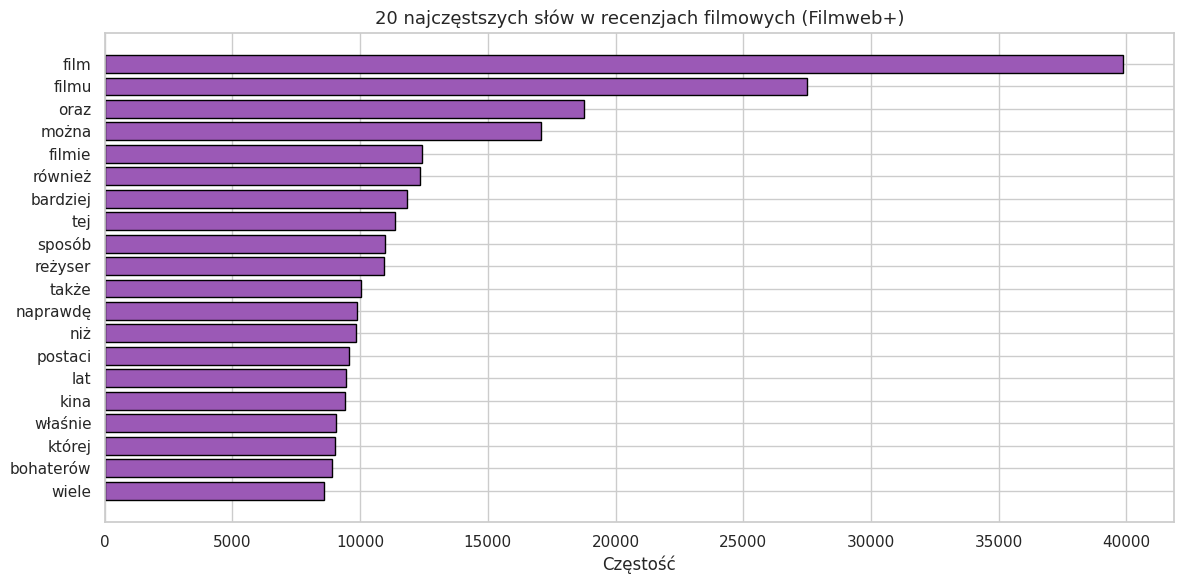

In [ ]:
words, counts = zip(*top_20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(words)), counts, color="#9b59b6", edgecolor="black")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Częstość")
ax.set_title("20 najczęstszych słów w recenzjach filmowych (Filmweb+)", fontsize=13)

plt.tight_layout()
plt.show()

### Interpretacja

Lista najczęstszych słów odzwierciedla domenę datasetu -- recenzje filmowe. Spodziewamy się słów takich jak "film", "reżyser", "aktor", "historia", "scena" itp. Warto zauważyć, że prosta tokenizacja i lista stopwordów nie są idealne -- w profesjonalnej analizie użylibyśmy lematyzatora (np. z biblioteki `spaCy` z modelem `pl_core_news_md`).

### 1.6 Najczęstsze słowa w podziale na sentyment

Sprawdźmy, czy charakterystyczne słowa różnią się w zależności od sentymentu recenzji.

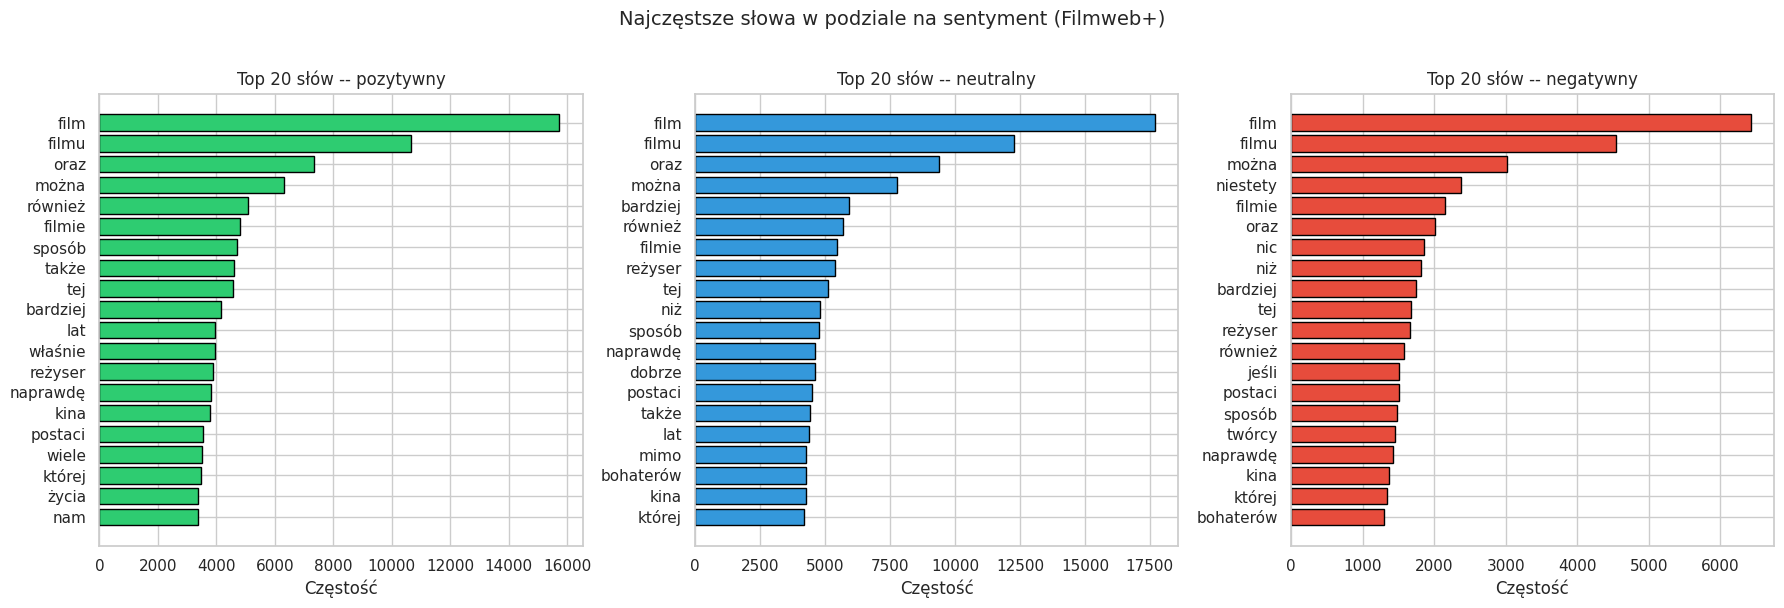

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (label, ax) in enumerate(zip(
    ["pozytywny", "neutralny", "negatywny"],
    axes.flatten()
)):
    subset = df_labeled[df_labeled["label"] == label]
    words_subset = []
    for text in subset["review"].dropna():
        tokens = tokenize_simple(text)
        filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
        words_subset.extend(filtered)

    top_20 = Counter(words_subset).most_common(20)
    if top_20:
        w, c = zip(*top_20)
        ax.barh(range(len(w)), c, color=colors[idx], edgecolor="black")
        ax.set_yticks(range(len(w)))
        ax.set_yticklabels(w)
        ax.invert_yaxis()
    ax.set_title(f"Top 20 słów -- {label}", fontsize=12)
    ax.set_xlabel("Częstość")

plt.suptitle("Najczęstsze słowa w podziale na sentyment (Filmweb+)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretacja

Porównanie najczęstszych słów między klasami może ujawnić, że np. w recenzjach pozytywnych dominują słowa oceniające, a w negatywnych -- słowa wyrażające rozczarowanie. To cenna informacja przy budowaniu modeli klasyfikacji sentymentu.

---
---
## 2. Zadanie do samodzielnej realizacji -- A

### Analiza recenzji nieoznaczonych vs oznaczonych

Porównaj recenzje **oznaczone** (sentiment ∈ {0, 1, 2}) z **nieoznaczonymi** (sentiment = -1).

**Wykonaj poniższe kroki:**

1. Oblicz **statystyki długości** (znaki i słowa) osobno dla recenzji oznaczonych i nieoznaczonych.
2. Porównaj rozkłady długości -- czy recenzje nieoznaczone mają inną charakterystykę?
3. Narysuj **histogram** porównujący rozkład długości tekstu między oznaczonymi a nieoznaczonymi na jednym wykresie.
4. Oblicz **średnią i medianę długości recenzji** (w słowach) dla każdej klasy sentymentu (0, 1, 2) i dla nieoznaczonych (-1).
5. Znajdź **najdłuższą** i **najkrótszą** recenzję w całym zbiorze. Wyświetl ich treść (pierwsze 500 znaków) i etykietę.
6. Sprawdź, czy występują **brakujące wartości** lub **puste recenzje** w zbiorze.

In [ ]:
# Krok 1: Statystyki długości dla oznaczonych i nieoznaczonych
# Wskazówka: dodaj kolumny num_chars i num_words do df_unlabeled, potem describe()



In [ ]:
# Krok 2: Porównanie rozkładów
# Wskazówka: użyj describe() na obu podzbiorach i porównaj wyniki



In [ ]:
# Krok 3: Histogram porównawczy oznaczone vs nieoznaczone
# Wskazówka: plt.hist([dane1, dane2], label=[...], alpha=0.7)



In [ ]:
# Krok 4: Średnia i mediana długości w podziale na klasy sentymentu
# Wskazówka: df.groupby("sentiment")["num_words"].agg(["mean", "median"])



In [ ]:
# Krok 5: Najdłuższa i najkrótsza recenzja
# Wskazówka: idxmax(), idxmin() na kolumnie z liczbą słów



In [ ]:
# Krok 6: Brakujące wartości i puste recenzje
# Wskazówka: df.isnull().sum(), df[df["review"].str.strip() == ""]



---
---
## 3. Zadanie do samodzielnej realizacji -- B

### Pogłębiona analiza sentymentu w Filmweb+

Skupiamy się na recenzjach oznaczonych (sentiment ∈ {0, 1, 2}) i przeprowadzamy pogłębioną analizę.

**Wykonaj poniższe kroki:**

1. Narysuj **rozkład długości recenzji** (w słowach) osobno dla każdej klasy sentymentu jako nałożone histogramy.
2. Oblicz **statystyki długości** tekstu (znaki i słowa) w podziale na sentyment za pomocą `groupby` i `agg`.
3. Narysuj **violin plot** długości tekstu w podziale na sentyment -- porównaj go z boxplotem.
4. Znajdź **10 najczęstszych słów** dla recenzji negatywnych (0) i pozytywnych (2). Porównaj je na jednym wykresie (subplots).
5. Oblicz **macierz korelacji** między długością tekstu (słowa i znaki) a sentymentem. Narysuj ją jako heatmapę.
6. Wyznacz **słowa charakterystyczne** dla każdej klasy -- znajdź słowa, które występują najczęściej w danej klasie, ale rzadko w pozostałych (np. stosunek częstości w klasie do częstości ogólnej).

In [ ]:
# Krok 1: Nałożone histogramy długości w podziale na sentyment
# Wskazówka: plt.hist() z alpha=0.5 dla każdej klasy osobno



In [ ]:
# Krok 2: Statystyki długości w podziale na sentyment
# Wskazówka: df_labeled.groupby("label")[["num_words", "num_chars"]].agg(["mean", "median", "std"])



In [ ]:
# Krok 3: Violin plot
# Wskazówka: sns.violinplot(data=df_labeled, x="label", y="num_words")



In [ ]:
# Krok 4: Top 10 słów dla negatywnych i pozytywnych
# Wskazówka: filtruj df_labeled, tokenizuj, Counter, porównaj na subplots



In [ ]:
# Krok 5: Macierz korelacji i heatmapa
# Wskazówka: df_labeled[["sentiment", "num_words", "num_chars"]].corr()
# sns.heatmap(corr, annot=True, cmap="coolwarm")



In [ ]:
# Krok 6: Słowa charakterystyczne dla każdej klasy
# Wskazówka: oblicz częstość słowa w klasie / częstość słowa ogólnie
# Filtruj słowa występujące min. 50 razy w klasie

